Step 1 - setup and feature extraction

In [ ]:
# step 1 - setup and feature extraction
import torch
import torchvision.transforms as transforms, torchvision
from torchvision.models.resnet import resnet18
import torchvision
import numpy as np
from simclr import SimCLR
from simclr.modules import NT_Xent
import os


# augmentations will need to be done here
# random resized crops - The algorithm takes a random section of the image
#  and resizes it back to the standard 32x32 pixel size
# Random horizontal flips
# Color jittering
# color jitter random apply - from the simclr github they used
# Random grayscaling


class ContrastiveTransformations(object):

    def __init__(self, base_transforms, n_views=2):
        self.base_transforms = base_transforms
        self.n_views = n_views

    def __call__(self, x):
        return [self.base_transforms(x) for i in range(self.n_views)]

base_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]),
])


if __name__ == '__main__':
    print("Downloading CIFAR 10")
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=True,
        download=True,
        transform=ContrastiveTransformations(base_transform)
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=512,
        shuffle=True,
        drop_last=True,
        num_workers=4,
        pin_memory=True
    )


    encoder = resnet18()
    n_features = encoder.fc.in_features
    model = SimCLR(encoder, projection_dim=128, n_features=n_features)


    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch is currently running on: {device}") 
    model = model.to(device)

    optimiser = torch.optim.SGD(
        model.parameters(),
        lr=0.4,
        momentum=0.9,
        weight_decay=0.0001
    )



    # things to do
    # use cosine thing for the learning rate




    criterion = NT_Xent(batch_size=512, temperature=0.5, world_size=1)

    epochs = 500

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimiser, T_max=epochs)

    start_epoch = 0
    checkpoint_path = 'simclr_checkpoint_epoch_save_checkpoint.pth'

    if os.path.exists(checkpoint_path):
        print(f"Found a save state! Resuming from '{checkpoint_path}'...")
        # Load the save file
        checkpoint = torch.load(checkpoint_path)
        
        # Restore the model, optimizer, and scheduler
        model.load_state_dict(checkpoint['model_state'])
        optimiser.load_state_dict(checkpoint['optimizer_state'])
        scheduler.load_state_dict(checkpoint['scheduler_state'])
        
        # Update the starting point
        start_epoch = checkpoint['epoch']
        print(f"Successfully loaded! Picking up at Epoch {start_epoch}...")
    else:
        print("No save state found. Starting fresh from Epoch 0!")


    print("training")
    for epoch in range(start_epoch, epochs):
        model.train()
        total_loss = 0

        for batch_idx, (images, _) in enumerate(train_loader):
            view1 = images[0].to(device)
            view2 = images[1].to(device)
            
            # 1. Wipe the old math memory
            optimiser.zero_grad()
            hi, hj, zi, zj = model(view1, view2)

            loss = criterion(zi, zj)

            loss.backward()

            optimiser.step()

            total_loss+= loss.item()

            if batch_idx % 50 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], Batch [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.4f}")



        avg_epoch_loss = total_loss / len(train_loader)
        print(f"--- End of Epoch {epoch+1} | Average Loss: {avg_epoch_loss:.4f} ---")

        scheduler.step()

        save_state = {
            'epoch': epoch + 1, # Save the NEXT epoch as the starting point
            'model_state': model.state_dict(),
            'optimizer_state': optimiser.state_dict(),
            'scheduler_state': scheduler.state_dict()
        }
        
        torch.save(save_state, checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")


    print("Training complete! Saving the final model...")
    torch.save(model.state_dict(), 'best_simclr_model_500_epochs.pth')
    print("Model saved successfully. You can now run feature extraction!")


In [22]:
import torch.nn.functional as F
from simclr import SimCLR
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.models.resnet import resnet18

# 1. Setup the device (just in case you run this tomorrow)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Build the shell with the CIFAR-10 fix
encoder = resnet18()
encoder.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
encoder.maxpool = nn.Identity()

n_features = encoder.fc.in_features
encoder.fc = nn.Identity()
loaded_model = SimCLR(encoder, projection_dim=128, n_features=n_features)
loaded_model = loaded_model.to(device)

# 2. Load the saved brain
saved_weights_path = 'model.pth.tar' 
checkpoint = torch.load(saved_weights_path, map_location=device)

# Extract JUST the model weights from the bundle
state_dict = checkpoint.get('model', checkpoint)

# Translate Kaggle language to Local language
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k
    name = name.replace('backbone.', 'encoder.') # Fix the main prefix
    name = name.replace('shortcut.', 'downsample.') # Fix the connection layers!
    
    new_state_dict[name] = v

# 3. Inject the cleaned weights
missing, unexpected = loaded_model.load_state_dict(new_state_dict, strict=False)
loaded_model.eval()

print(f"✅ Weights loaded!")
print(f"Missing keys from ResNet: {sum(1 for k in missing if 'encoder' in k)}")
# clean transform

clean_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

clean_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=clean_transform
)

clean_loader = torch.utils.data.DataLoader(
    clean_dataset,
    batch_size=512,
    shuffle=False
)

# k means if k is less than 50 other minibatch k means


loaded_model.eval()

all_features = []
all_labels = []

with torch.no_grad():
    print("Features")

    for images, labels in clean_loader:
        images = images.to(device)
        
        features = loaded_model.encoder(images)

        all_features.append(features.cpu())
        all_labels.append(labels.cpu())


all_features = torch.cat(all_features, dim=0)
all_labels = torch.cat(all_labels, dim=0)

all_features_normalized = F.normalize(all_features, p=2, dim=1)

print(f"Extraction complete! Final array shape: {all_features_normalized.shape}")

C:\Users\arnav\AppData\Local\Temp\ipykernel_4132\823121469.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(saved_weights_path, map_location=devi

✅ Weights loaded!
Missing keys from ResNet: 0
Features
Extraction complete! Final array shape: torch.Size([50000, 512])


In [27]:
from sklearn.cluster import KMeans
import numpy as np
# k means clustering

label_budget = 30

features_np = all_features_normalized.numpy()

k_means_algorithm = KMeans(n_clusters=label_budget, random_state=42, n_init='auto')

k_means_algorithm.fit(features_np)

final_typical_images = []

from sklearn.neighbors import NearestNeighbors

cluster_assignments = k_means_algorithm.labels_

nearest = NearestNeighbors(n_neighbors=20, algorithm='brute', n_jobs=-1)

for i in range(label_budget):
    cluster_i = np.where(cluster_assignments == i)[0]

    cluster_features = features_np[cluster_i]

    fit = nearest.fit(cluster_features)

    distance, indicies = fit.kneighbors(cluster_features)


    average_distances = distance.mean(axis=1)

    

    typicality_score = 1 / (average_distances + 1e-8)



    best = np.argmax(typicality_score)

    best_id = cluster_i[best]

    final_typical_images.append(best_id)

    print(f"Cluster {i} winner: Image #{best_id}")


print("All done! Here are your 30 typical images:", final_typical_images)

Cluster 0 winner: Image #9162
Cluster 1 winner: Image #43764
Cluster 2 winner: Image #33264
Cluster 3 winner: Image #42315
Cluster 4 winner: Image #18668
Cluster 5 winner: Image #16995
Cluster 6 winner: Image #19677
Cluster 7 winner: Image #40430
Cluster 8 winner: Image #41360
Cluster 9 winner: Image #12071
Cluster 10 winner: Image #30397
Cluster 11 winner: Image #30141
Cluster 12 winner: Image #45266
Cluster 13 winner: Image #24602
Cluster 14 winner: Image #23817
Cluster 15 winner: Image #16255
Cluster 16 winner: Image #16189
Cluster 17 winner: Image #17387
Cluster 18 winner: Image #23288
Cluster 19 winner: Image #32061
Cluster 20 winner: Image #21294
Cluster 21 winner: Image #28692
Cluster 22 winner: Image #43062
Cluster 23 winner: Image #40502
Cluster 24 winner: Image #9178
Cluster 25 winner: Image #18573
Cluster 26 winner: Image #22589
Cluster 27 winner: Image #14714
Cluster 28 winner: Image #27823
Cluster 29 winner: Image #12943
All done! Here are your 30 typical images: [np.int64

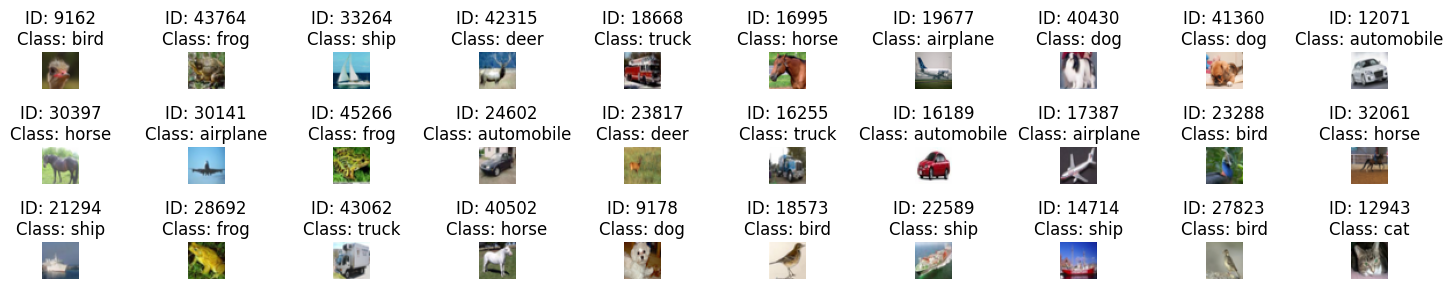

In [28]:
import matplotlib.pyplot as plt

#final_typical_images = [42076, 26315, 24916, 32635, 12071, 41009, 26783]   

fig, axes = plt.subplots(3, 10, figsize=(15, 3))
axes = axes.flatten()

for idx, image_id in enumerate(final_typical_images):
 
    img_tensor, true_label_id = clean_dataset[image_id]
    
  
    class_name = clean_dataset.classes[true_label_id]
    
  
    img_display = np.transpose(img_tensor.numpy(), (1, 2, 0))
    
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img_display = std * img_display + mean

    img_display = np.clip(img_display, 0, 1)
   
    axes[idx].imshow(img_display)
    axes[idx].set_title(f"ID: {image_id}\nClass: {class_name}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Convert your PyTorch tensor into a NumPy array for Scikit-Learn
features_to_plot = all_features_normalized.numpy()

# 2. The Heavy Math
print("Running t-SNE... this takes a few minutes!")
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
features_2d = tsne.fit_transform(features_to_plot)
print("t-SNE complete!")

# 3. Set up the canvas
plt.figure(figsize=(10, 8))

# 4. Plot all 50,000 background dots
# You already generated 'cluster_assignments' in your loop above!
plt.scatter(
    features_2d[:, 0], 
    features_2d[:, 1], 
    c=cluster_assignments, 
    cmap='tab10', 
    alpha=0.3, 
    s=15       
)

# 5. Highlight the 7 typical images you found
typical_x = features_2d[final_typical_images, 0]
typical_y = features_2d[final_typical_images, 1]

plt.scatter(
    typical_x, 
    typical_y, 
    c='red', 
    marker='*', 
    s=350, 
    edgecolor='black',
    label=f'Typical Images (Budget={label_budget})'
)

# 6. Formatting
plt.title("t-SNE Representation of TypiClust Clusters", fontsize=14, fontweight='bold')
plt.legend()
plt.axis('off') 

# Save directly to your folder for Overleaf
plt.savefig('tsne_typiclust.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# linear classficiation model

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

X_train = all_features_normalized[final_typical_images].to(device)
y_train = all_labels[final_typical_images].to(device)

classifier = nn.Linear(512, 10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=2.5)

epochs = 200
classifier.train()

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = classifier(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()


test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=512, shuffle=False)

# 5. The Final Exam
loaded_model.eval()
classifier.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Step A: Pass test images through your frozen SimCLR encoder
        features = loaded_model.encoder(images)
        
        # Step B: Normalize the test features (must match what we did to the train features!)
        features = F.normalize(features, p=2, dim=1)
        
        # Step C: Pass the translated features into your tiny classifier
        outputs = classifier(features)
        
        # Step D: See if it guessed right
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()


final_accuracy = 100 * correct / total
print(f"==========================================")
print(f"FINAL TYPICLUST ACCURACY (30 Labels): {final_accuracy:.2f}%")
print(f"==========================================")

Files already downloaded and verified


c:\Users\arnav\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


FINAL TYPICLUST ACCURACY (30 Labels): 68.62%
